In [4]:

import sys
import os

# Add parent directory to the Python path
sys.path.append(os.path.abspath("../../.."))

import lightning as L
import numpy as np
import pandas as pd
import seaborn as sns
import torch

# from data_models import sample_data_model
from lightning.pytorch.callbacks import ModelCheckpoint, TQDMProgressBar
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from NCP.model import NCPModule, NCPOperator
from NCP.nn.layers import MLP
from NCP.nn.losses import CMELoss
from NCP.utils import FastTensorDataLoader, from_np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from torch.optim import Adam


def sample_data_model(
    sample_size=200,
):
    X = stats.norm.rvs(size=(sample_size, 1))
    Y = stats.norm.rvs(size=(sample_size, 1))

    ntrain, nval = (int(0.9 * sample_size), int(0.1 * sample_size))

    X_train, Y_train = X[:ntrain], Y[:ntrain]
    X_val, Y_val = X[ntrain : ntrain + nval], Y[ntrain : ntrain + nval]

    xscaler = StandardScaler()
    yscaler = StandardScaler()

    X_train = xscaler.fit_transform(X_train)
    Y_train = yscaler.fit_transform(Y_train)

    X_val = xscaler.transform(X_val)
    Y_val = yscaler.transform(Y_val)

    X_train_torch = from_np(X_train)
    Y_train_torch = from_np(Y_train)
    X_val_torch = from_np(X_val)
    Y_val_torch = from_np(Y_val)

    return X_train_torch, X_val_torch, Y_train_torch, Y_val_torch


# TODO: Ugly, remove
class NCPModelCheckpoint(ModelCheckpoint):
    def on_save_checkpoint(self, trainer, pl_module, checkpoint):
        X, Y = trainer.model.batch
        trainer.model.model._compute_data_statistics(X, Y)
        checkpoint["state_dict"] = trainer.model.state_dict()


def unbind_namespace(dict):
    """Remove first namespace from dictionary keys.

    Main use case: load state dict and remove "model" prefix.
    e.g., 'model._mean_Ux' => '_mean_Ux'.
    """
    return {".".join(k.split(".")[1:]): v for (k, v) in dict.items()}


def make_ncp(latent_dim=50):
    MLP_kwargs_U = {
        "input_shape": 1,
        "output_shape": latent_dim,
        "n_hidden": 2,
        "layer_size": 32,
        "dropout": 0,
        "iterative_whitening": False,
        "activation": torch.nn.GELU,
    }

    MLP_kwargs_V = {
        "input_shape": 1,
        "output_shape": latent_dim,
        "n_hidden": 2,
        "layer_size": 32,
        "dropout": 0,
        "iterative_whitening": False,
        "activation": torch.nn.GELU,
    }

    return (
        NCPOperator(
            U_operator=MLP,
            V_operator=MLP,
            U_operator_kwargs=MLP_kwargs_U,
            V_operator_kwargs=MLP_kwargs_V,
        ),
        MLP_kwargs_U,
        MLP_kwargs_V,
    )


def experiment(sample_size, latent_dim):
    ########## NOTE: Sample from data model
    X_train_torch, X_val_torch, Y_train_torch, Y_val_torch = sample_data_model(
        sample_size=sample_size
    )

    train_dl = FastTensorDataLoader(
        X_train_torch, Y_train_torch, batch_size=len(X_train_torch), shuffle=False
    )
    val_dl = FastTensorDataLoader(
        X_val_torch, Y_val_torch, batch_size=len(X_val_torch), shuffle=False
    )
    ##########

    ########## NOTE: Fit
    ncp_operator, MLP_kwargs_U, MLP_kwargs_V = make_ncp()
    model = NCPModule(
        ncp_operator,
        optimizer_fn=Adam,
        optimizer_kwargs={"lr": 1e-3},
        loss_fn=CMELoss,
        loss_kwargs={"mode": "split", "gamma": 1e-2},
    )

    checkpoint = NCPModelCheckpoint(
        filename="NCP",
        save_top_k=1,
        monitor="val_loss",
        mode="min",
    )

    trainer = L.Trainer(
        accelerator="gpu",
        devices=1,
        precision="bf16-mixed",
        num_sanity_val_steps=0,
        max_epochs=5000,
        enable_model_summary=False,
        log_every_n_steps=1,
        callbacks=[
            # TQDMProgressBar(leave=False),
            EarlyStopping(monitor="val_loss", mode="min", patience=50),
            checkpoint,
        ],
    )

    trainer.fit(
        model,
        train_dataloaders=train_dl,
        val_dataloaders=val_dl,
    )
    ##########

    # FIXME: Ugly hack for loading registered buffers that have different size than the ones
    #   registered during NCPOperator.__init__. My bet is that the linalg involved in computing
    #   singular vectors at '_compute_data_statistics' yields a variable number of sing_vecs,
    #   which breaks Module.load_state_dict'.
    ncp_state = unbind_namespace(
        torch.load(
            f"{checkpoint.dirpath}/NCP.ckpt",
            weights_only=False,
            map_location=torch.device("cpu"),  # can be removed if using GPU
        )["state_dict"]
    )
    keys_to_pop = [
        "_mean_Ux",
        "_mean_Vy",
        "_sqrt_cov_X_inv",
        "_sqrt_cov_Y_inv",
        "_sing_val",
        "_sing_vec_l",
        "_sing_vec_r",
    ]
    popped_items = {k: ncp_state.pop(k) for k in keys_to_pop}
    ncp = NCPOperator(
        U_operator=MLP,
        V_operator=MLP,
        U_operator_kwargs=MLP_kwargs_U,
        V_operator_kwargs=MLP_kwargs_V,
    )
    ncp.load_state_dict(ncp_state, strict=False)
    for stat, value in popped_items.items():
        ncp.__setattr__(stat, value)

    sing_val = ncp.state_dict()["_sing_val"]
    # Effective rank
    return sing_val.sum().item() / sing_val.max().item()

<Axes: ylabel='Count'>

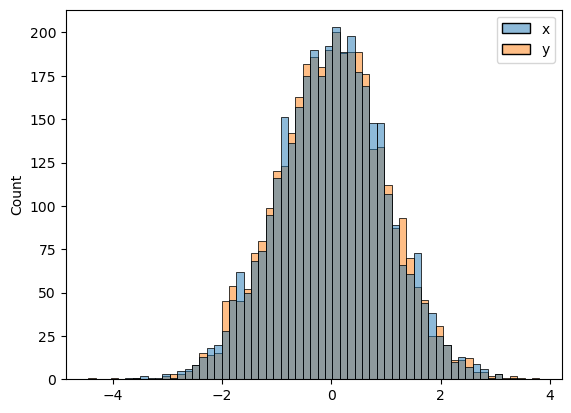

In [5]:
X, _, Y, __ = sample_data_model(4000)
sns.histplot(data=pd.DataFrame({"x": X.squeeze(), "y": Y.squeeze()}))

In [6]:
import logging
from itertools import product

param_grid = {
    "sample_size": [200, 400, 1000, 5000],
    # "latent_dim": [1] + list(range(5, 55, 5)),
    "latent_dim": [1, 2, 3, 4, 5],
}

logging.getLogger("pytorch_lightning").setLevel(logging.CRITICAL)

result = dict()
for sample_size, latent_dim in product(*param_grid.values()):
    result[(sample_size, latent_dim)] = experiment(
        sample_size=sample_size,
        latent_dim=latent_dim,
    )

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 78: 100%|██████████| 1/1 [00:00<00:00, 15.17it/s, v_num=6, val_loss=1.290, train_loss=0.915]


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 231: 100%|██████████| 1/1 [00:00<00:00, 16.48it/s, v_num=7, val_loss=0.853, train_loss=0.931]


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


...

Epoch 176: 100%|██████████| 1/1 [00:00<00:00, 17.05it/s, v_num=23, val_loss=0.972, train_loss=0.953]


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 169: 100%|██████████| 1/1 [00:00<00:00, 18.06it/s, v_num=24, val_loss=0.980, train_loss=0.949]


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 173: 100%|██████████| 1/1 [00:00<00:00, 18.18it/s, v_num=25, val_loss=0.948, train_loss=0.955]


In [9]:
result
# result = pd.DataFrame(
#     data=[(ss, lt, n) for (ss, lt), n in result.items()],
#     columns=["sample_size", "latent_dim", "effective_rank"],
# )

,sample_size,latent_dim,effective_rank
0,200,1,3.204613
1,200,2,2.645901
2,200,3,2.785085
3,200,4,2.937827
4,200,5,2.556931
5,400,1,2.965697
6,400,2,1.827360
7,400,3,2.229007
8,400,4,2.919038
9,400,5,2.858378


In [10]:
result

,sample_size,latent_dim,effective_rank
0,200,1,3.204613
1,200,2,2.645901
2,200,3,2.785085
3,200,4,2.937827
4,200,5,2.556931
5,400,1,2.965697
6,400,2,1.827360
7,400,3,2.229007
8,400,4,2.919038
9,400,5,2.858378


<Axes: xlabel='latent_dim', ylabel='effective_rank'>

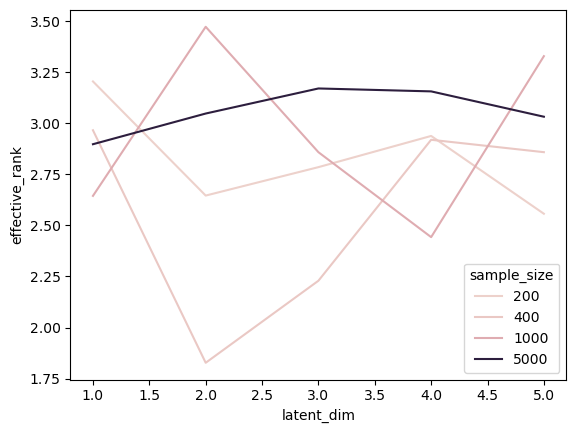

In [11]:
sns.lineplot(result, x="latent_dim", y="effective_rank", hue="sample_size")